## Q6 - Derivative of Gaussian


### 1 - State the Derivative Formulas (Part a)

Given the two-dimensional Gaussian function:


$
G(x,y)=\frac{1}{2\pi\sigma^2}\exp\left(-\frac{x^2+y^2}{2\sigma^2}\right)
$

its first-order partial derivatives are:

$
\frac{\partial G}{\partial x}=-\frac{x}{\sigma^2}G(x,y)
$

$
\frac{\partial G}{\partial y}=-\frac{y}{\sigma^2}G(x,y)
$


### 2 - Import Required Libraries


In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D


### 3 - Set Input and Output Paths


In [36]:
img_path = Path("../data/raw/rice.png")   # change if needed
out_dir = Path("../results/q06")
out_dir.mkdir(parents=True, exist_ok=True)

print("Input path:", img_path.resolve())
print("Output folder:", out_dir.resolve())


Input path: D:\MSc in AI\1YQ3\CV\Assignment_1\data\raw\rice.png
Output folder: D:\MSc in AI\1YQ3\CV\Assignment_1\results\q06


### 4 - Load Grayscale Image


In [37]:
img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Could not load image: {img_path}")

print("Image loaded successfully")
print("Shape:", img.shape)
print("Data type:", img.dtype)


Image loaded successfully
Shape: (256, 256)
Data type: uint8


### 5 - Display Original Image

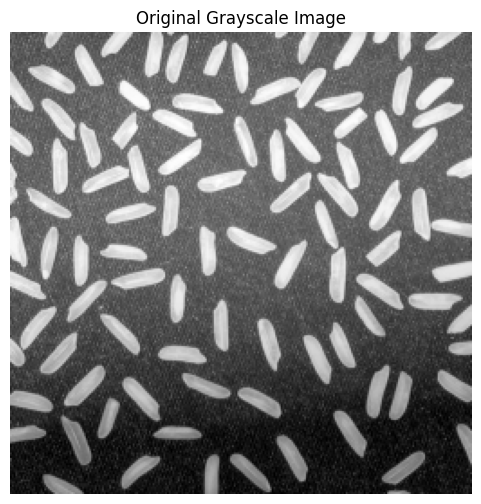

In [38]:
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()


### 6 - Define Gaussian and Derivative-of-Gaussian Functions (Part b)

In [39]:
def gaussian(size, sigma):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)

    g = (1 / (2 * np.pi * sigma**2)) * np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return g, xx, yy


def dog_kernels(size, sigma):
    """
    Compute derivative-of-Gaussian kernels in x and y directions.
    """
    g, xx, yy = gaussian(size, sigma)

    gx = -(xx / sigma**2) * g
    gy = -(yy / sigma**2) * g

    gx = gx / np.sum(np.abs(gx))
    gy = gy / np.sum(np.abs(gy))

    return gx, gy, xx, yy


### 7 - Compute 5x5 DoG Kernels (Part b)

In [40]:
gx_5, gy_5, _, _ = dog_kernels(5, 2)

print("5x5 Derivative of Gaussian Kernel in x-direction (sigma = 2):")
print(gx_5)
print()
print("5x5 Derivative of Gaussian Kernel in y-direction (sigma = 2):")
print(gy_5)


5x5 Derivative of Gaussian Kernel in x-direction (sigma = 2):
[[ 0.04413011  0.03210446 -0.         -0.03210446 -0.04413011]
 [ 0.06420893  0.04671172 -0.         -0.04671172 -0.06420893]
 [ 0.07275825  0.05293131 -0.         -0.05293131 -0.07275825]
 [ 0.06420893  0.04671172 -0.         -0.04671172 -0.06420893]
 [ 0.04413011  0.03210446 -0.         -0.03210446 -0.04413011]]

5x5 Derivative of Gaussian Kernel in y-direction (sigma = 2):
[[ 0.04413011  0.06420893  0.07275825  0.06420893  0.04413011]
 [ 0.03210446  0.04671172  0.05293131  0.04671172  0.03210446]
 [-0.         -0.         -0.         -0.         -0.        ]
 [-0.03210446 -0.04671172 -0.05293131 -0.04671172 -0.03210446]
 [-0.04413011 -0.06420893 -0.07275825 -0.06420893 -0.04413011]]


### 8 - Visualize 5x5 DoG Kernels (Part c)

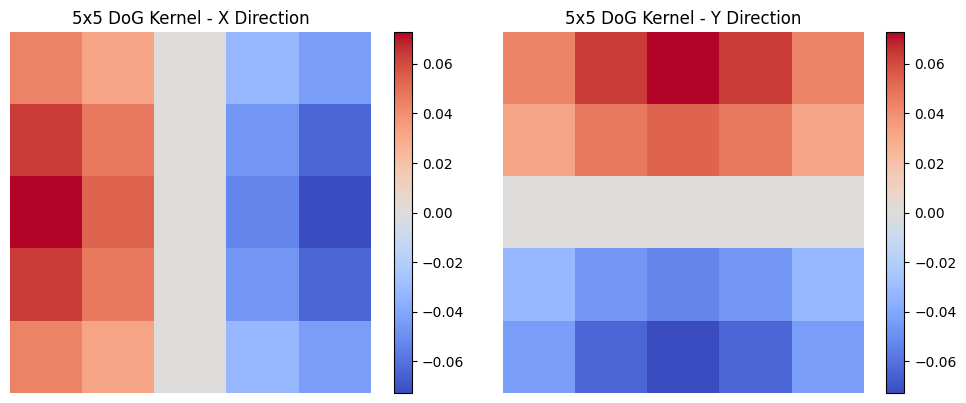

In [41]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gx_5, cmap="coolwarm")
plt.title("5x5 DoG Kernel - X Direction")
plt.colorbar()
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gy_5, cmap="coolwarm")
plt.title("5x5 DoG Kernel - Y Direction")
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()


### 9 - Compute 51x51 DoG Kernel (Part c)

In [42]:
gx_51, gy_51, xx_51, yy_51 = dog_kernels(51, 2)


### 10 - Plot 3D Surface of DoG Kernel (Part c)

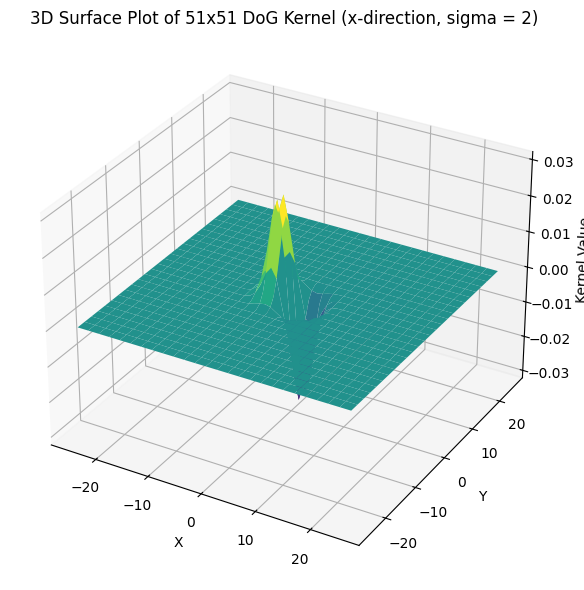

In [43]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(xx_51, yy_51, gx_51, cmap="viridis")

ax.set_title("3D Surface Plot of 51x51 DoG Kernel (x-direction, sigma = 2)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Kernel Value")

plt.tight_layout()
plt.show()


### 11 - Apply Derivative-of-Gaussian Filters (Part d)

In [44]:
grad_x = cv2.filter2D(img.astype(np.float32), -1, gx_5)
grad_y = cv2.filter2D(img.astype(np.float32), -1, gy_5)

grad_mag = np.sqrt(grad_x**2 + grad_y**2)

print("Derivative-of-Gaussian filtering completed.")


Derivative-of-Gaussian filtering completed.


### 12 - Normalize Gradient Images for Display (Part d)

In [45]:
grad_x_disp = cv2.normalize(np.abs(grad_x), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
grad_y_disp = cv2.normalize(np.abs(grad_y), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
grad_mag_disp = cv2.normalize(grad_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


### 13 - Display DoG Gradient Results (Part d)

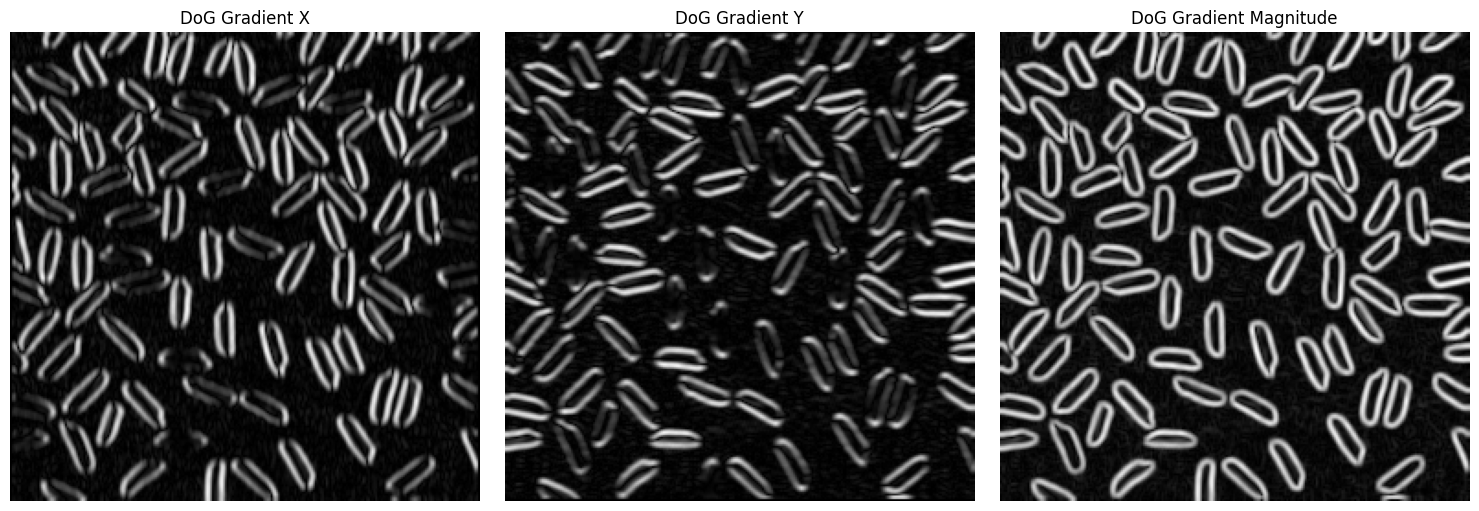

In [46]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(grad_x_disp, cmap="gray")
plt.title("DoG Gradient X")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(grad_y_disp, cmap="gray")
plt.title("DoG Gradient Y")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(grad_mag_disp, cmap="gray")
plt.title("DoG Gradient Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()


### 14 - Compute Sobel Gradients (Part c)

In [47]:
sobel_x = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=5)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

print("Sobel gradient computation completed.")


Sobel gradient computation completed.


### 15 - Normalize Sobel Images for Display (Part c)

In [48]:
sobel_x_disp = cv2.normalize(np.abs(sobel_x), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
sobel_y_disp = cv2.normalize(np.abs(sobel_y), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
sobel_mag_disp = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


### 16 - Display Sobel Gradient Results (Part c)

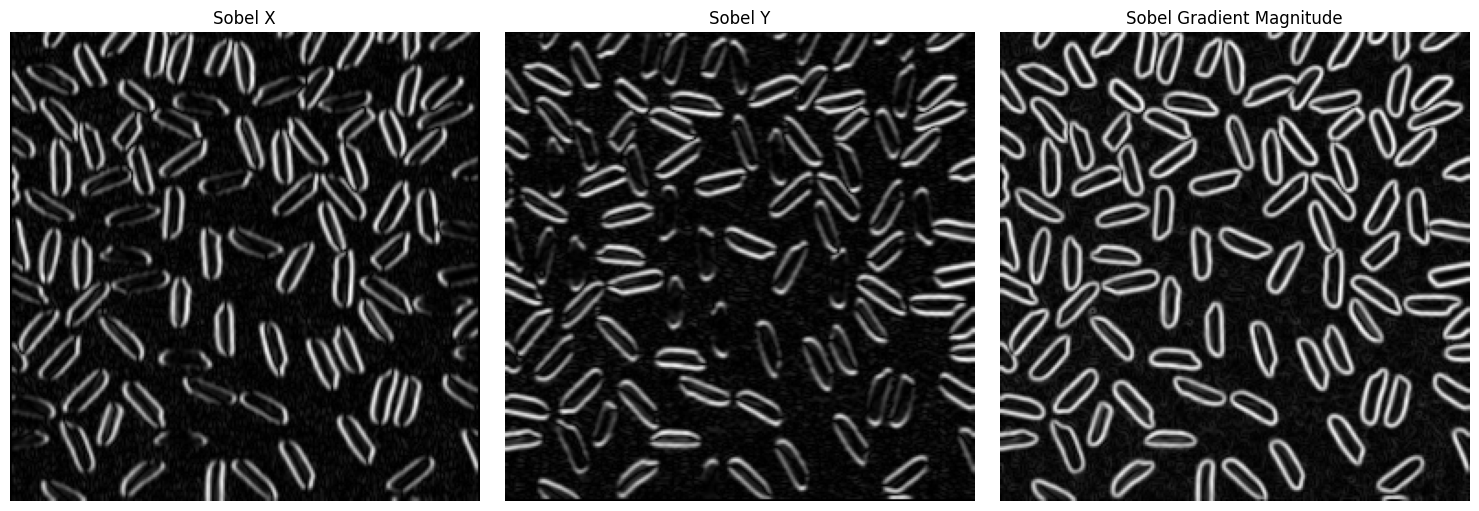

In [49]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sobel_x_disp, cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sobel_y_disp, cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sobel_mag_disp, cmap="gray")
plt.title("Sobel Gradient Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()


### 17 - Compare DoG and Sobel Results (Part c)

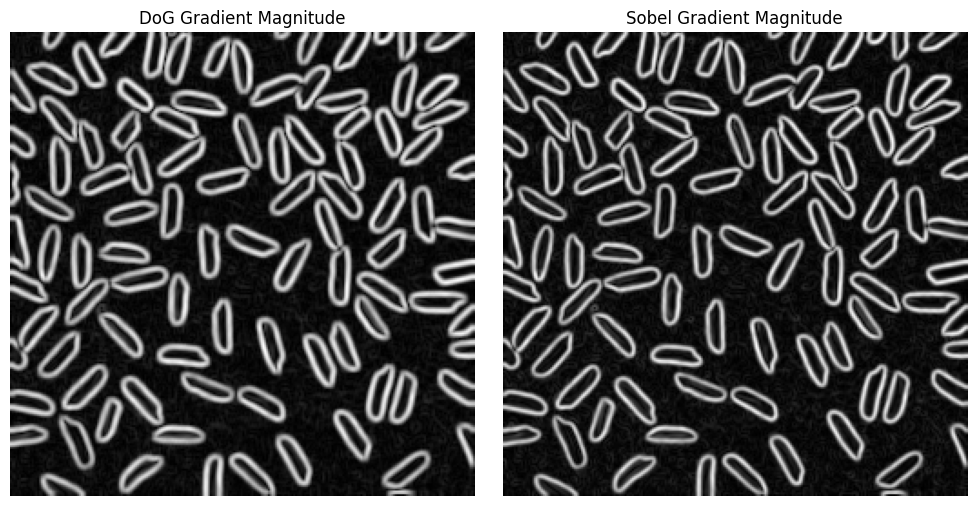

In [50]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(grad_mag_disp, cmap="gray")
plt.title("DoG Gradient Magnitude")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sobel_mag_disp, cmap="gray")
plt.title("Sobel Gradient Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()


### 18 - Save Output Images

In [51]:
cv2.imwrite(str(out_dir / "q06_grad_x_dog.png"), grad_x_disp)
cv2.imwrite(str(out_dir / "q06_grad_y_dog.png"), grad_y_disp)
cv2.imwrite(str(out_dir / "q06_grad_mag_dog.png"), grad_mag_disp)
cv2.imwrite(str(out_dir / "q06_sobel_x.png"), sobel_x_disp)
cv2.imwrite(str(out_dir / "q06_sobel_y.png"), sobel_y_disp)
cv2.imwrite(str(out_dir / "q06_sobel_mag.png"), sobel_mag_disp)

print(f"Saved DoG x-gradient to: {out_dir / 'q06_grad_x_dog.png'}")
print(f"Saved DoG y-gradient to: {out_dir / 'q06_grad_y_dog.png'}")
print(f"Saved DoG magnitude to: {out_dir / 'q06_grad_mag_dog.png'}")
print(f"Saved Sobel x-gradient to: {out_dir / 'q06_sobel_x.png'}")
print(f"Saved Sobel y-gradient to: {out_dir / 'q06_sobel_y.png'}")
print(f"Saved Sobel magnitude to: {out_dir / 'q06_sobel_mag.png'}")


Saved DoG x-gradient to: ..\results\q06\q06_grad_x_dog.png
Saved DoG y-gradient to: ..\results\q06\q06_grad_y_dog.png
Saved DoG magnitude to: ..\results\q06\q06_grad_mag_dog.png
Saved Sobel x-gradient to: ..\results\q06\q06_sobel_x.png
Saved Sobel y-gradient to: ..\results\q06\q06_sobel_y.png
Saved Sobel magnitude to: ..\results\q06\q06_sobel_mag.png


## Interpretation and Discussion

The derivative-of-Gaussian kernels were computed analytically from the Gaussian function for the x and y directions. These kernels respond strongly to horizontal and vertical intensity changes, respectively.

When applied to the grayscale image, the x-direction kernel highlights vertical edges, while the y-direction kernel highlights horizontal edges. The gradient magnitude combines both responses to show the overall edge strength.

The Sobel operator also estimates image gradients, but it uses a standard discrete derivative kernel rather than the analytically derived Gaussian derivative. In practice, the derivative-of-Gaussian result is often smoother because the Gaussian component provides built-in smoothing before differentiation. Sobel may produce slightly sharper or noisier edges depending on the image content.
